<a href="https://colab.research.google.com/github/tirthpatel1111/redundant-question-pair/blob/main/duplicat_qa_pair.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install spacy

In [ ]:
import spacy

In [ ]:
nlp=spacy.load('en_core_web_sm')

In [ ]:
doc=nlp(u'I will google about facebook')

In [ ]:
doc.text

'I will google about facebook'

In [ ]:
doc[0]

I

In [ ]:
doc[1].pos_

'AUX'

In [ ]:
doc[1].tag_

'MD'

In [ ]:
spacy.explain('MD')

'verb, modal auxiliary'

In [ ]:
doc

I will google about facebook

In [ ]:
for word in doc:
  print(word.text,'------->',word.pos_,word.tag_,spacy.explain(word.tag_))

I -------> PRON PRP pronoun, personal
will -------> AUX MD verb, modal auxiliary
google -------> VERB VB verb, base form
about -------> ADP IN conjunction, subordinating or preposition
facebook -------> PROPN NNP noun, proper singular


In [ ]:
doc2=nlp('i left the room')

In [ ]:
for word in doc2:
  print(word.text,'--------->',word.pos_,word.tag_,spacy.explain(word.tag_))

i ---------> PRON PRP pronoun, personal
left ---------> VERB VBD verb, past tense
the ---------> DET DT determiner
room ---------> NOUN NN noun, singular or mass


In [ ]:
doc3=nlp(u'to the left of the room')

In [ ]:
for word in doc3:
  print(word.text,'---------->',word.pos_,word.tag_,spacy.explain(word.tag_))

to ----------> ADP IN conjunction, subordinating or preposition
the ----------> DET DT determiner
left ----------> NOUN NN noun, singular or mass
of ----------> ADP IN conjunction, subordinating or preposition
the ----------> DET DT determiner
room ----------> NOUN NN noun, singular or mass


In [ ]:
doc6=nlp('The quick brown fox jumped over the lazy dog')

In [ ]:
for word in doc6:
  print(word.text,'-------->',word.pos_,word.tag_,spacy.explain(word.tag_))

The --------> DET DT determiner
quick --------> ADJ JJ adjective (English), other noun-modifier (Chinese)
brown --------> ADJ JJ adjective (English), other noun-modifier (Chinese)
fox --------> NOUN NN noun, singular or mass
jumped --------> VERB VBD verb, past tense
over --------> ADP IN conjunction, subordinating or preposition
the --------> DET DT determiner
lazy --------> ADJ JJ adjective (English), other noun-modifier (Chinese)
dog --------> NOUN NN noun, singular or mass


In [ ]:
from spacy import displacy

In [ ]:
displacy.render(doc6,style='dep',jupyter=True)

In [ ]:
options={
    'distance':80,
    'compact':True,
    'color':'#fff',
    'bg':'#00a65a'
}

In [ ]:
displacy.render(doc6,style='dep',jupyter=True,options=options)

## Duplicate Question Pairs

In [ ]:
!mkdir -p ~/.kaggle # creating .kaggle folder to store kaggle file
!cp kaggle.json ~/.kaggle/

In [ ]:
!kaggle datasets download -d quora/question-pairs-dataset

Dataset URL: https://www.kaggle.com/datasets/quora/question-pairs-dataset
License(s): other
  0% 0.00/20.8M [00:00<?, ?B/s]
100% 20.8M/20.8M [00:00<00:00, 818MB/s]


In [ ]:
!unzip /content/question-pairs-dataset.zip

Archive:  /content/question-pairs-dataset.zip
  inflating: questions.csv           


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/questions.csv')

In [ ]:
df.head(5)

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404351 entries, 0 to 404350
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404351 non-null  int64 
 1   qid1          404351 non-null  int64 
 2   qid2          404351 non-null  int64 
 3   question1     404350 non-null  object
 4   question2     404349 non-null  object
 5   is_duplicate  404351 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


In [ ]:
df.isnull().sum()

,0
id,0
qid1,0
qid2,0
question1,1
question2,2
is_duplicate,0


In [ ]:
df=df.dropna()

In [ ]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


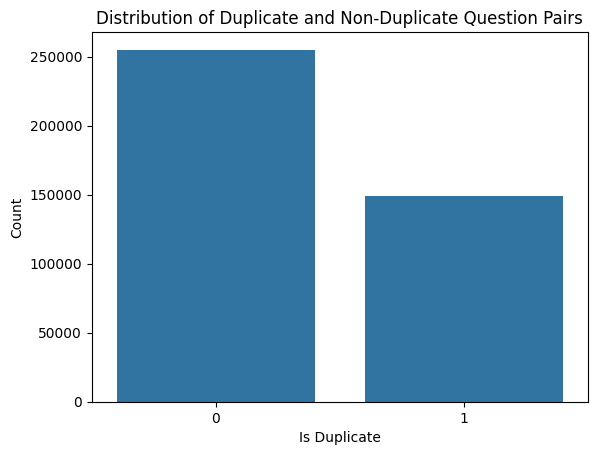

In [ ]:
sns.countplot(x='is_duplicate', data=df)
plt.title('Distribution of Duplicate and Non-Duplicate Question Pairs')
plt.xlabel('Is Duplicate')
plt.ylabel('Count')
plt.show()

In [ ]:
df.shape

(404348, 6)

In [ ]:
qid=pd.Series(df['qid1'].tolist()+df['qid2'].tolist())

In [ ]:
np.unique(qid).shape

(789795,)

In [ ]:
x=qid.value_counts()>1

In [ ]:
x.shape

(789795,)

In [ ]:
x[x]

,count
65333,True
7863,True
147324,True
2628,True
196396,True
...,...
1492,True
208937,True
405833,True
113851,True


In [ ]:
print("questions which are repeted",x[x].shape)

questions which are repeted (13698,)


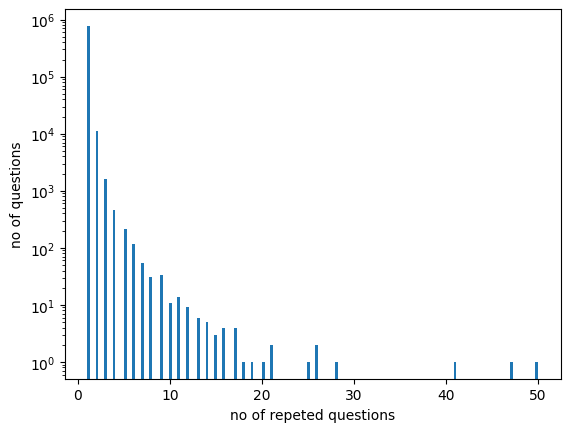

In [ ]:
plt.hist(qid.value_counts().values,bins=160)
plt.yscale('log')
plt.xlabel('no of repeted questions')
plt.ylabel('no of questions')
plt.show()

In [ ]:
new_df=df.sample(30000,random_state=2)

In [ ]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate
302477,302477,594007,594008,What are kalman filters used for?,What are examples of filters used in a home?,0
369857,369857,723787,723788,How do Relationship work?,What matters in the life most dignity or money?,0
4665,4665,9325,9326,How would an arbitrageur seek to capitalize gi...,How would an arbitrageur seek to capitalize gi...,0
54203,54203,107861,107862,Why did Quora mark my question as incomplete?,Why does Quora detect my question as an incomp...,1
132567,132567,262555,262556,Does Google Maps account for change in speed w...,What speed does Google Maps assume when it gen...,1


In [ ]:
new_df.isna().sum()

,0
id,0
qid1,0
qid2,0
question1,0
question2,0
is_duplicate,0


In [ ]:
new_df['is_duplicate'].value_counts()

,count
is_duplicate,
0,19073
1,10927


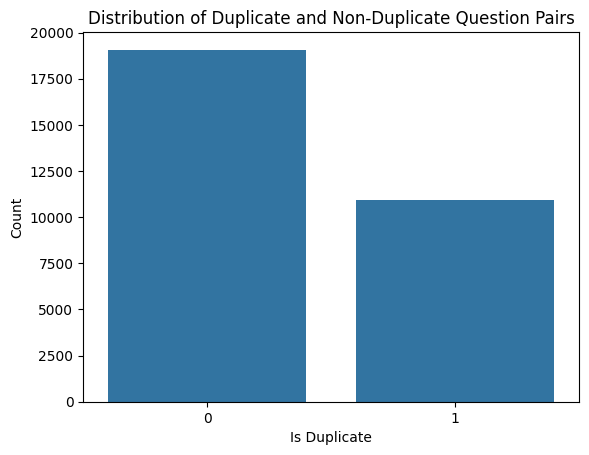

In [ ]:
sns.countplot(x='is_duplicate',data=new_df)
plt.title('Distribution of Duplicate and Non-Duplicate Question Pairs')
plt.xlabel('Is Duplicate')
plt.ylabel('Count')
plt.show()

In [ ]:
qid=pd.Series(new_df['qid1'].tolist()+new_df['qid2'])
print("number of unique",np.unique(qid).shape[0])

number of unique 29963


In [ ]:
x=qid.value_counts()>1
print("number of questions which are repeated",x[x].shape[0])

number of questions which are repeated 37


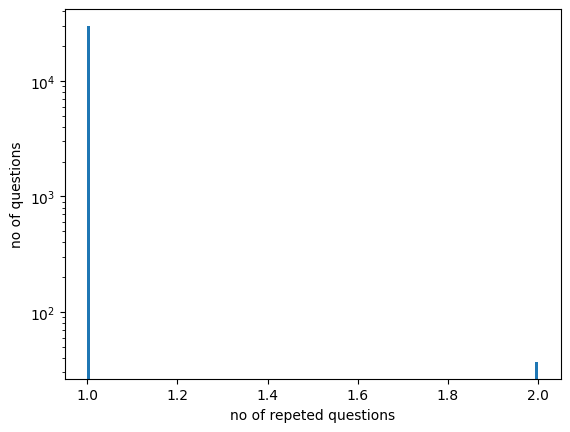

In [ ]:
plt.hist(qid.value_counts().values,bins=160)
plt.yscale('log')
plt.xlabel('no of repeted questions')
plt.ylabel('no of questions')
plt.show()

In [ ]:
new_df['que1_len']=new_df['question1'].str.len()
new_df['que2_len']=new_df['question2'].str.len()

In [ ]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,que1_len,que2_len
302477,302477,594007,594008,What are kalman filters used for?,What are examples of filters used in a home?,0,33,44
369857,369857,723787,723788,How do Relationship work?,What matters in the life most dignity or money?,0,25,47
4665,4665,9325,9326,How would an arbitrageur seek to capitalize gi...,How would an arbitrageur seek to capitalize gi...,0,125,124
54203,54203,107861,107862,Why did Quora mark my question as incomplete?,Why does Quora detect my question as an incomp...,1,45,60
132567,132567,262555,262556,Does Google Maps account for change in speed w...,What speed does Google Maps assume when it gen...,1,71,84


In [ ]:
new_df['num_que1_words']=new_df['question1'].apply(lambda x:len(x.split(" ")))

In [ ]:
new_df['num_que2_words']=new_df['question2'].apply(lambda x:len(x.split(" ")))

In [ ]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,que1_len,que2_len,num_que1_words,num_que2_words
302477,302477,594007,594008,What are kalman filters used for?,What are examples of filters used in a home?,0,33,44,6,9
369857,369857,723787,723788,How do Relationship work?,What matters in the life most dignity or money?,0,25,47,4,9
4665,4665,9325,9326,How would an arbitrageur seek to capitalize gi...,How would an arbitrageur seek to capitalize gi...,0,125,124,24,24
54203,54203,107861,107862,Why did Quora mark my question as incomplete?,Why does Quora detect my question as an incomp...,1,45,60,8,10
132567,132567,262555,262556,Does Google Maps account for change in speed w...,What speed does Google Maps assume when it gen...,1,71,84,12,14


In [ ]:
def num_common_word(row):
  q1=set(map(lambda x:x.lower().strip(),row['question1'].split(" ")))
  q2=set(map(lambda x:x.lower().strip(),row['question2'].split(" ")))
  return len(q1&q2)

In [ ]:
new_df['common_words']=df.apply(num_common_word,axis=1)

In [ ]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,que1_len,que2_len,num_que1_words,num_que2_words,common_words
302477,302477,594007,594008,What are kalman filters used for?,What are examples of filters used in a home?,0,33,44,6,9,4
369857,369857,723787,723788,How do Relationship work?,What matters in the life most dignity or money?,0,25,47,4,9,0
4665,4665,9325,9326,How would an arbitrageur seek to capitalize gi...,How would an arbitrageur seek to capitalize gi...,0,125,124,24,24,20
54203,54203,107861,107862,Why did Quora mark my question as incomplete?,Why does Quora detect my question as an incomp...,1,45,60,8,10,5
132567,132567,262555,262556,Does Google Maps account for change in speed w...,What speed does Google Maps assume when it gen...,1,71,84,12,14,6


In [ ]:
def total_word(row):
  q1=set(map(lambda x:x.lower().strip(),row['question1'].split(" ")))
  q2=set(map(lambda x:x.lower().strip(),row['question2'].split(" ")))
  return (len(q1)+len(q2))

In [ ]:
new_df['total_words']=df.apply(total_word,axis=1)

In [ ]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,que1_len,que2_len,num_que1_words,num_que2_words,common_words,total_words
302477,302477,594007,594008,What are kalman filters used for?,What are examples of filters used in a home?,0,33,44,6,9,4,15
369857,369857,723787,723788,How do Relationship work?,What matters in the life most dignity or money?,0,25,47,4,9,0,13
4665,4665,9325,9326,How would an arbitrageur seek to capitalize gi...,How would an arbitrageur seek to capitalize gi...,0,125,124,24,24,20,42
54203,54203,107861,107862,Why did Quora mark my question as incomplete?,Why does Quora detect my question as an incomp...,1,45,60,8,10,5,18
132567,132567,262555,262556,Does Google Maps account for change in speed w...,What speed does Google Maps assume when it gen...,1,71,84,12,14,6,26


In [ ]:
new_df['word_share']=round(new_df['common_words']/new_df['total_words'],2)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,que1_len,que2_len,num_que1_words,num_que2_words,common_words,total_words,word_share
302477,302477,594007,594008,What are kalman filters used for?,What are examples of filters used in a home?,0,33,44,6,9,4,15,0.27
369857,369857,723787,723788,How do Relationship work?,What matters in the life most dignity or money?,0,25,47,4,9,0,13,0.00
4665,4665,9325,9326,How would an arbitrageur seek to capitalize gi...,How would an arbitrageur seek to capitalize gi...,0,125,124,24,24,20,42,0.48
54203,54203,107861,107862,Why did Quora mark my question as incomplete?,Why does Quora detect my question as an incomp...,1,45,60,8,10,5,18,0.28
132567,132567,262555,262556,Does Google Maps account for change in speed w...,What speed does Google Maps assume when it gen...,1,71,84,12,14,6,26,0.23


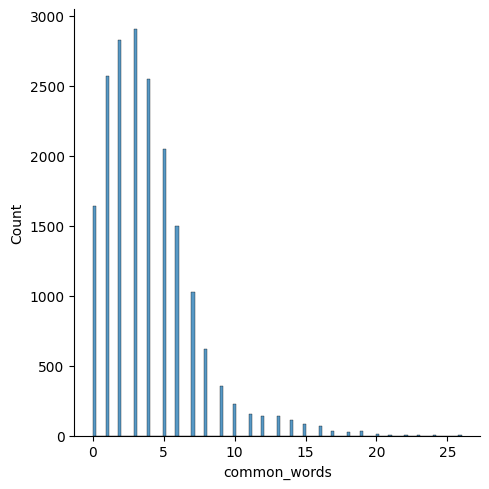

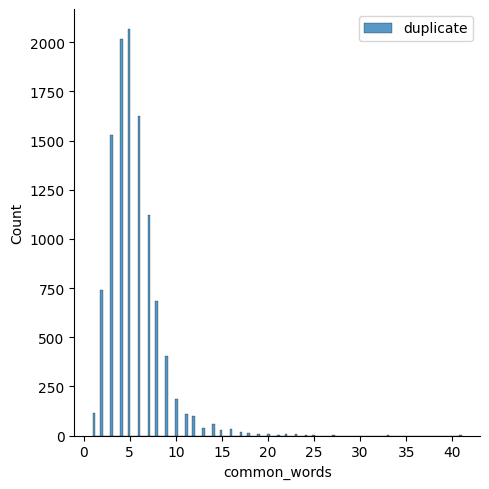

In [ ]:
sns.displot(new_df[new_df['is_duplicate']==0]['common_words'],label='not duplicate')
sns.displot(new_df[new_df['is_duplicate']==1]['common_words'],label='duplicate')
plt.legend()
plt.show()


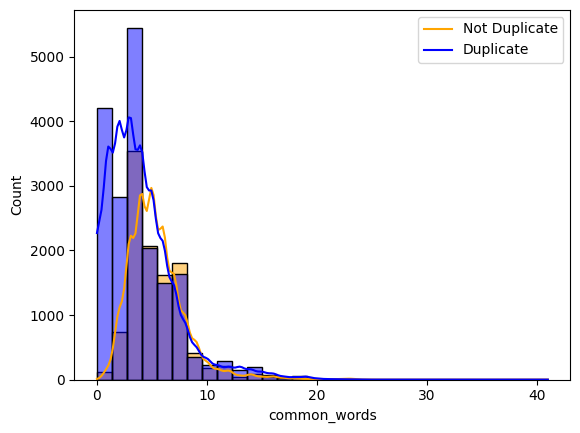

In [ ]:

sns.histplot(
    data=new_df,
    x='common_words',
    hue='is_duplicate',
    kde='hist',
    bins=30,
    palette=['blue', 'orange'],
    # alpha=0.5
)

plt.legend(labels=['Not Duplicate', 'Duplicate'])
plt.show()


In [ ]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,que1_len,que2_len,num_que1_words,num_que2_words,common_words,total_words,word_share
302477,302477,594007,594008,What are kalman filters used for?,What are examples of filters used in a home?,0,33,44,6,9,4,15,0.27
369857,369857,723787,723788,How do Relationship work?,What matters in the life most dignity or money?,0,25,47,4,9,0,13,0.00
4665,4665,9325,9326,How would an arbitrageur seek to capitalize gi...,How would an arbitrageur seek to capitalize gi...,0,125,124,24,24,20,42,0.48
54203,54203,107861,107862,Why did Quora mark my question as incomplete?,Why does Quora detect my question as an incomp...,1,45,60,8,10,5,18,0.28
132567,132567,262555,262556,Does Google Maps account for change in speed w...,What speed does Google Maps assume when it gen...,1,71,84,12,14,6,26,0.23


In [ ]:
final_df=new_df[['id','qid1','qid2','is_duplicate','que1_len','que2_len','num_que1_words','num_que2_words','common_words','total_words','word_share']]

In [ ]:
que_df=new_df[['question1','question2']]
que_df.head()

,question1,question2
302477,What are kalman filters used for?,What are examples of filters used in a home?
369857,How do Relationship work?,What matters in the life most dignity or money?
4665,How would an arbitrageur seek to capitalize gi...,How would an arbitrageur seek to capitalize gi...
54203,Why did Quora mark my question as incomplete?,Why does Quora detect my question as an incomp...
132567,Does Google Maps account for change in speed w...,What speed does Google Maps assume when it gen...


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
question=list(que_df['question1'])+list(que_df['question2'])

In [ ]:
cv=CountVectorizer(max_features=3000)

In [ ]:
q1_arr,q2_arr=np.vsplit(cv.fit_transform(question).toarray(),2)

In [ ]:
temp_df1=pd.DataFrame(q1_arr,index=que_df.index)
temp_df2=pd.DataFrame(q2_arr,index=que_df.index)
temp_df=pd.concat([temp_df1,temp_df2],axis=1)
temp_df.shape

(30000, 6000)

In [ ]:
final_df

,id,qid1,qid2,is_duplicate,que1_len,que2_len,num_que1_words,num_que2_words,common_words,total_words,word_share
302477,302477,594007,594008,0,33,44,6,9,4,15,0.27
369857,369857,723787,723788,0,25,47,4,9,0,13,0.00
4665,4665,9325,9326,0,125,124,24,24,20,42,0.48
54203,54203,107861,107862,1,45,60,8,10,5,18,0.28
132567,132567,262555,262556,1,71,84,12,14,6,26,0.23
...,...,...,...,...,...,...,...,...,...,...,...
314121,314121,1368,616492,0,72,59,12,8,6,20,0.30
142895,142895,282814,282815,0,38,28,6,4,3,10,0.30
43027,43027,74406,85695,0,42,76,8,17,4,24,0.17
154199,154199,304984,304985,0,80,81,14,14,13,28,0.46


In [ ]:
final_df=pd.concat([final_df,temp_df],axis=1)

In [ ]:
final_df.head()

,id,qid1,qid2,is_duplicate,que1_len,que2_len,num_que1_words,num_que2_words,common_words,total_words,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
302477,302477,594007,594008,0,33,44,6,9,4,15,...,0,0,0,0,0,0,0,0,0,0
369857,369857,723787,723788,0,25,47,4,9,0,13,...,0,0,0,0,0,0,0,0,0,0
4665,4665,9325,9326,0,125,124,24,24,20,42,...,0,0,0,0,0,0,0,0,0,0
54203,54203,107861,107862,1,45,60,8,10,5,18,...,0,0,0,0,0,0,0,0,0,0
132567,132567,262555,262556,1,71,84,12,14,6,26,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
final_df.drop(['id','qid1','qid2'],axis=1,inplace=True)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x=final_df.iloc[:,1:].values
y=final_df.iloc[:,0].values

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

re=RandomForestClassifier()
re.fit(x_train,y_train)
y_pred=re.predict(x_test)
accuracy_score(y_test,y_pred)

0.7616666666666667

Pefrom Preprocessing and create a model

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from bs4 import BeautifulSoup
import warnings
warnings.filterwarnings('ignore')


In [ ]:
df = pd.read_csv('questions.csv')

In [ ]:
def preprocess(q):

    q = str(q).lower().strip()

    # Replace certain special characters with their string equivalents
    q = q.replace('%', ' percent')
    q = q.replace('$', ' dollar ')
    q = q.replace('₹', ' rupee ')
    q = q.replace('€', ' euro ')
    q = q.replace('@', ' at ')

    # The pattern '[math]' appears around 900 times in the whole dataset.
    q = q.replace('[math]', '')

    # Replacing some numbers with string equivalents (not perfect, can be done better to account for more cases)
    q = q.replace(',000,000,000 ', 'b ')
    q = q.replace(',000,000 ', 'm ')
    q = q.replace(',000 ', 'k ')
    q = re.sub(r'([0-9]+)000000000', r'\1b', q)
    q = re.sub(r'([0-9]+)000000', r'\1m', q)
    q = re.sub(r'([0-9]+)000', r'\1k', q)

    # Decontracting words
    # https://en.wikipedia.org/wiki/Wikipedia%3aList_of_English_contractions
    # https://stackoverflow.com/a/19794953
    contractions = {
    "ain't": "am not",
    "aren't": "are not",
    "can't": "can not",
    "can't've": "can not have",
    "'cause": "because",
    "could've": "could have",
    "couldn't": "could not",
    "couldn't've": "could not have",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hadn't've": "had not have",
    "hasn't": "has not",
    "haven't": "have not",
    "he'd": "he would",
    "he'd've": "he would have",
    "he'll": "he will",
    "he'll've": "he will have",
    "he's": "he is",
    "how'd": "how did",
    "how'd'y": "how do you",
    "how'll": "how will",
    "how's": "how is",
    "i'd": "i would",
    "i'd've": "i would have",
    "i'll": "i will",
    "i'll've": "i will have",
    "i'm": "i am",
    "i've": "i have",
    "isn't": "is not",
    "it'd": "it would",
    "it'd've": "it would have",
    "it'll": "it will",
    "it'll've": "it will have",
    "it's": "it is",
    "let's": "let us",
    "ma'am": "madam",
    "mayn't": "may not",
    "might've": "might have",
    "mightn't": "might not",
    "mightn't've": "might not have",
    "must've": "must have",
    "mustn't": "must not",
    "mustn't've": "must not have",
    "needn't": "need not",
    "needn't've": "need not have",
    "o'clock": "of the clock",
    "oughtn't": "ought not",
    "oughtn't've": "ought not have",
    "shan't": "shall not",
    "sha'n't": "shall not",
    "shan't've": "shall not have",
    "she'd": "she would",
    "she'd've": "she would have",
    "she'll": "she will",
    "she'll've": "she will have",
    "she's": "she is",
    "should've": "should have",
    "shouldn't": "should not",
    "shouldn't've": "should not have",
    "so've": "so have",
    "so's": "so as",
    "that'd": "that would",
    "that'd've": "that would have",
    "that's": "that is",
    "there'd": "there would",
    "there'd've": "there would have",
    "there's": "there is",
    "they'd": "they would",
    "they'd've": "they would have",
    "they'll": "they will",
    "they'll've": "they will have",
    "they're": "they are",
    "they've": "they have",
    "to've": "to have",
    "wasn't": "was not",
    "we'd": "we would",
    "we'd've": "we would have",
    "we'll": "we will",
    "we'll've": "we will have",
    "we're": "we are",
    "we've": "we have",
    "weren't": "were not",
    "what'll": "what will",
    "what'll've": "what will have",
    "what're": "what are",
    "what's": "what is",
    "what've": "what have",
    "when's": "when is",
    "when've": "when have",
    "where'd": "where did",
    "where's": "where is",
    "where've": "where have",
    "who'll": "who will",
    "who'll've": "who will have",
    "who's": "who is",
    "who've": "who have",
    "why's": "why is",
    "why've": "why have",
    "will've": "will have",
    "won't": "will not",
    "won't've": "will not have",
    "would've": "would have",
    "wouldn't": "would not",
    "wouldn't've": "would not have",
    "y'all": "you all",
    "y'all'd": "you all would",
    "y'all'd've": "you all would have",
    "y'all're": "you all are",
    "y'all've": "you all have",
    "you'd": "you would",
    "you'd've": "you would have",
    "you'll": "you will",
    "you'll've": "you will have",
    "you're": "you are",
    "you've": "you have"
    }

    q_decontracted = []

    for word in q.split():
        if word in contractions:
            word = contractions[word]

        q_decontracted.append(word)

    q = ' '.join(q_decontracted)
    q = q.replace("'ve", " have")
    q = q.replace("n't", " not")
    q = q.replace("'re", " are")
    q = q.replace("'ll", " will")

    # Removing HTML tags
    q = BeautifulSoup(q)
    q = q.get_text()

    # Remove punctuations
    pattern = re.compile('\W')
    q = re.sub(pattern, ' ', q).strip()


    return q


In [ ]:
preprocess("I've already! wasn't <b>done</b>?")

'i have already  was not done'

In [ ]:
new_df['question1'] = new_df['question1'].apply(preprocess)
new_df['question2'] = new_df['question2'].apply(preprocess)

In [ ]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,que1_len,que2_len,num_que1_words,num_que2_words,common_words,total_words,word_share
302477,302477,594007,594008,what are kalman filters used for,what are examples of filters used in a home,0,33,44,6,9,4,15,0.27
369857,369857,723787,723788,how do relationship work,what matters in the life most dignity or money,0,25,47,4,9,0,13,0.00
4665,4665,9325,9326,how would an arbitrageur seek to capitalize gi...,how would an arbitrageur seek to capitalize gi...,0,125,124,24,24,20,42,0.48
54203,54203,107861,107862,why did quora mark my question as incomplete,why does quora detect my question as an incomp...,1,45,60,8,10,5,18,0.28
132567,132567,262555,262556,does google maps account for change in speed w...,what speed does google maps assume when it gen...,1,71,84,12,14,6,26,0.23


In [ ]:
new_df['q1_len'] = new_df['question1'].str.len()
new_df['q2_len'] = new_df['question2'].str.len()

In [ ]:
new_df['q1_num_words'] = new_df['question1'].apply(lambda row: len(row.split(" ")))
new_df['q2_num_words'] = new_df['question2'].apply(lambda row: len(row.split(" ")))
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,que1_len,que2_len,num_que1_words,num_que2_words,common_words,total_words,word_share,q1_len,q2_len,q1_num_words,q2_num_words
302477,302477,594007,594008,what are kalman filters used for,what are examples of filters used in a home,0,33,44,6,9,4,15,0.27,32,43,6,9
369857,369857,723787,723788,how do relationship work,what matters in the life most dignity or money,0,25,47,4,9,0,13,0.00,24,46,4,9
4665,4665,9325,9326,how would an arbitrageur seek to capitalize gi...,how would an arbitrageur seek to capitalize gi...,0,125,124,24,24,20,42,0.48,123,122,42,42
54203,54203,107861,107862,why did quora mark my question as incomplete,why does quora detect my question as an incomp...,1,45,60,8,10,5,18,0.28,44,59,8,10
132567,132567,262555,262556,does google maps account for change in speed w...,what speed does google maps assume when it gen...,1,71,84,12,14,6,26,0.23,70,83,12,14


In [ ]:
def common_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
    return len(w1 & w2)

In [ ]:
new_df['word_common'] = new_df.apply(common_words, axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,que1_len,que2_len,num_que1_words,num_que2_words,common_words,total_words,word_share,q1_len,q2_len,q1_num_words,q2_num_words,word_common
302477,302477,594007,594008,what are kalman filters used for,what are examples of filters used in a home,0,33,44,6,9,4,15,0.27,32,43,6,9,4
369857,369857,723787,723788,how do relationship work,what matters in the life most dignity or money,0,25,47,4,9,0,13,0.00,24,46,4,9,0
4665,4665,9325,9326,how would an arbitrageur seek to capitalize gi...,how would an arbitrageur seek to capitalize gi...,0,125,124,24,24,20,42,0.48,123,122,42,42,18
54203,54203,107861,107862,why did quora mark my question as incomplete,why does quora detect my question as an incomp...,1,45,60,8,10,5,18,0.28,44,59,8,10,6
132567,132567,262555,262556,does google maps account for change in speed w...,what speed does google maps assume when it gen...,1,71,84,12,14,6,26,0.23,70,83,12,14,6


In [ ]:
def total_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
    return (len(w1) + len(w2))

In [ ]:
new_df['word_total'] = new_df.apply(total_words, axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,que1_len,que2_len,num_que1_words,num_que2_words,common_words,total_words,word_share,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total
302477,302477,594007,594008,what are kalman filters used for,what are examples of filters used in a home,0,33,44,6,9,4,15,0.27,32,43,6,9,4,15
369857,369857,723787,723788,how do relationship work,what matters in the life most dignity or money,0,25,47,4,9,0,13,0.00,24,46,4,9,0,13
4665,4665,9325,9326,how would an arbitrageur seek to capitalize gi...,how would an arbitrageur seek to capitalize gi...,0,125,124,24,24,20,42,0.48,123,122,42,42,18,38
54203,54203,107861,107862,why did quora mark my question as incomplete,why does quora detect my question as an incomp...,1,45,60,8,10,5,18,0.28,44,59,8,10,6,18
132567,132567,262555,262556,does google maps account for change in speed w...,what speed does google maps assume when it gen...,1,71,84,12,14,6,26,0.23,70,83,12,14,6,26


In [ ]:
new_df['word_share'] = round(new_df['word_common']/new_df['word_total'],2)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,que1_len,que2_len,num_que1_words,num_que2_words,common_words,total_words,word_share,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total
302477,302477,594007,594008,what are kalman filters used for,what are examples of filters used in a home,0,33,44,6,9,4,15,0.27,32,43,6,9,4,15
369857,369857,723787,723788,how do relationship work,what matters in the life most dignity or money,0,25,47,4,9,0,13,0.00,24,46,4,9,0,13
4665,4665,9325,9326,how would an arbitrageur seek to capitalize gi...,how would an arbitrageur seek to capitalize gi...,0,125,124,24,24,20,42,0.47,123,122,42,42,18,38
54203,54203,107861,107862,why did quora mark my question as incomplete,why does quora detect my question as an incomp...,1,45,60,8,10,5,18,0.33,44,59,8,10,6,18
132567,132567,262555,262556,does google maps account for change in speed w...,what speed does google maps assume when it gen...,1,71,84,12,14,6,26,0.23,70,83,12,14,6,26


In [ ]:
# Advanced Features
from nltk.corpus import stopwords

def fetch_token_features(row):

    q1 = row['question1']
    q2 = row['question2']

    SAFE_DIV = 0.0001

    STOP_WORDS = stopwords.words("english")

    token_features = [0.0]*8

    # Converting the Sentence into Tokens:
    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return token_features

    # Get the non-stopwords in Questions
    q1_words = set([word for word in q1_tokens if word not in STOP_WORDS])
    q2_words = set([word for word in q2_tokens if word not in STOP_WORDS])

    #Get the stopwords in Questions
    q1_stops = set([word for word in q1_tokens if word in STOP_WORDS])
    q2_stops = set([word for word in q2_tokens if word in STOP_WORDS])

    # Get the common non-stopwords from Question pair
    common_word_count = len(q1_words.intersection(q2_words))

    # Get the common stopwords from Question pair
    common_stop_count = len(q1_stops.intersection(q2_stops))

    # Get the common Tokens from Question pair
    common_token_count = len(set(q1_tokens).intersection(set(q2_tokens)))


    token_features[0] = common_word_count / (min(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[1] = common_word_count / (max(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[2] = common_stop_count / (min(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[3] = common_stop_count / (max(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[4] = common_token_count / (min(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
    token_features[5] = common_token_count / (max(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)

    # Last word of both question is same or not
    token_features[6] = int(q1_tokens[-1] == q2_tokens[-1])

    # First word of both question is same or not
    token_features[7] = int(q1_tokens[0] == q2_tokens[0])

    return token_features

In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
token_features = new_df.apply(fetch_token_features, axis=1)

new_df["cwc_min"]       = list(map(lambda x: x[0], token_features))
new_df["cwc_max"]       = list(map(lambda x: x[1], token_features))
new_df["csc_min"]       = list(map(lambda x: x[2], token_features))
new_df["csc_max"]       = list(map(lambda x: x[3], token_features))
new_df["ctc_min"]       = list(map(lambda x: x[4], token_features))
new_df["ctc_max"]       = list(map(lambda x: x[5], token_features))
new_df["last_word_eq"]  = list(map(lambda x: x[6], token_features))
new_df["first_word_eq"] = list(map(lambda x: x[7], token_features))

In [ ]:

new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,que1_len,que2_len,num_que1_words,num_que2_words,...,word_common,word_total,cwc_min,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq
302477,302477,594007,594008,what are kalman filters used for,what are examples of filters used in a home,0,33,44,6,9,...,4,15,0.666644,0.499988,0.666644,0.399992,0.666656,0.444440,0.0,1.0
369857,369857,723787,723788,how do relationship work,what matters in the life most dignity or money,0,25,47,4,9,...,0,13,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
4665,4665,9325,9326,how would an arbitrageur seek to capitalize gi...,how would an arbitrageur seek to capitalize gi...,0,125,124,24,24,...,18,38,0.923070,0.923070,0.999980,0.999980,0.708330,0.708330,1.0,1.0
54203,54203,107861,107862,why did quora mark my question as incomplete,why does quora detect my question as an incomp...,1,45,60,8,10,...,6,18,0.749981,0.599988,0.749981,0.599988,0.749991,0.599994,0.0,1.0
132567,132567,262555,262556,does google maps account for change in speed w...,what speed does google maps assume when it gen...,1,71,84,12,14,...,6,26,0.374995,0.333330,0.749981,0.599988,0.499996,0.428568,0.0,0.0


In [ ]:
!pip install distance

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.3/180.3 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for distance: filename=Distance-0.1.3-py3-none-any.whl size=16256 sha256=6ab15cafe96e118d7925cada99e542e0fa2624c765313cb4ce371459746c3ac3
  Stored in directory: /root/.cache/pip/wheels/fb/cd/9c/3ab5d666e3bcacc58900b10959edd3816cc9557c7337986322
Successfully built distance


In [ ]:
import distance

def fetch_length_features(row):

    q1 = row['question1']
    q2 = row['question2']

    length_features = [0.0]*3

    # Converting the Sentence into Tokens:
    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return length_features

    # Absolute length features
    length_features[0] = abs(len(q1_tokens) - len(q2_tokens))

    #Average Token Length of both Questions
    length_features[1] = (len(q1_tokens) + len(q2_tokens))/2

    strs = list(distance.lcsubstrings(q1, q2))
    length_features[2] = len(strs[0]) / (min(len(q1), len(q2)) + 1)

    return length_features

In [ ]:
length_features = new_df.apply(fetch_length_features, axis=1)

new_df['abs_len_diff'] = list(map(lambda x: x[0], length_features))
new_df['mean_len'] = list(map(lambda x: x[1], length_features))
new_df['longest_substr_ratio'] = list(map(lambda x: x[2], length_features))

In [ ]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,que1_len,que2_len,num_que1_words,num_que2_words,...,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio
302477,302477,594007,594008,what are kalman filters used for,what are examples of filters used in a home,0,33,44,6,9,...,0.499988,0.666644,0.399992,0.666656,0.444440,0.0,1.0,3.0,7.5,0.424242
369857,369857,723787,723788,how do relationship work,what matters in the life most dignity or money,0,25,47,4,9,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,5.0,6.5,0.080000
4665,4665,9325,9326,how would an arbitrageur seek to capitalize gi...,how would an arbitrageur seek to capitalize gi...,0,125,124,24,24,...,0.923070,0.999980,0.999980,0.708330,0.708330,1.0,1.0,0.0,24.0,0.593496
54203,54203,107861,107862,why did quora mark my question as incomplete,why does quora detect my question as an incomp...,1,45,60,8,10,...,0.599988,0.749981,0.599988,0.749991,0.599994,0.0,1.0,2.0,9.0,0.355556
132567,132567,262555,262556,does google maps account for change in speed w...,what speed does google maps assume when it gen...,1,71,84,12,14,...,0.333330,0.749981,0.599988,0.499996,0.428568,0.0,0.0,2.0,13.0,0.253521


In [ ]:
!pip install fuzzywuzzy

In [ ]:
from fuzzywuzzy import fuzz

def fetch_fuzzy_features(row):

    q1 = row['question1']
    q2 = row['question2']

    fuzzy_features = [0.0]*4

    # fuzz_ratio
    fuzzy_features[0] = fuzz.QRatio(q1, q2)

    # fuzz_partial_ratio
    fuzzy_features[1] = fuzz.partial_ratio(q1, q2)

    # token_sort_ratio
    fuzzy_features[2] = fuzz.token_sort_ratio(q1, q2)

    # token_set_ratio
    fuzzy_features[3] = fuzz.token_set_ratio(q1, q2)

    return fuzzy_features

In [ ]:
fuzzy_features = new_df.apply(fetch_fuzzy_features, axis=1)

# Creating new feature columns for fuzzy features
new_df['fuzz_ratio'] = list(map(lambda x: x[0], fuzzy_features))
new_df['fuzz_partial_ratio'] = list(map(lambda x: x[1], fuzzy_features))
new_df['token_sort_ratio'] = list(map(lambda x: x[2], fuzzy_features))
new_df['token_set_ratio'] = list(map(lambda x: x[3], fuzzy_features))

In [ ]:
print(new_df.shape)
new_df.head()

(30000, 34)


,id,qid1,qid2,question1,question2,is_duplicate,que1_len,que2_len,num_que1_words,num_que2_words,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
302477,302477,594007,594008,what are kalman filters used for,what are examples of filters used in a home,0,33,44,6,9,...,0.444440,0.0,1.0,3.0,7.5,0.424242,69,72,61,79
369857,369857,723787,723788,how do relationship work,what matters in the life most dignity or money,0,25,47,4,9,...,0.000000,0.0,0.0,5.0,6.5,0.080000,23,33,34,34
4665,4665,9325,9326,how would an arbitrageur seek to capitalize gi...,how would an arbitrageur seek to capitalize gi...,0,125,124,24,24,...,0.708330,1.0,1.0,0.0,24.0,0.593496,100,99,100,99
54203,54203,107861,107862,why did quora mark my question as incomplete,why does quora detect my question as an incomp...,1,45,60,8,10,...,0.599994,0.0,1.0,2.0,9.0,0.355556,74,75,74,89
132567,132567,262555,262556,does google maps account for change in speed w...,what speed does google maps assume when it gen...,1,71,84,12,14,...,0.428568,0.0,0.0,2.0,13.0,0.253521,50,54,71,72


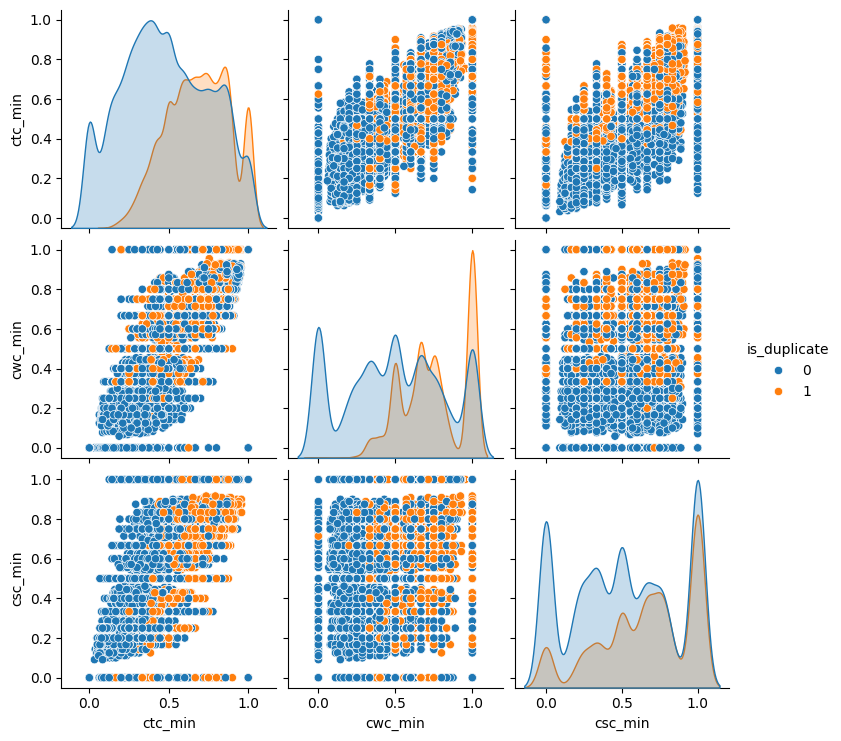

In [ ]:
sns.pairplot(new_df[['ctc_min', 'cwc_min', 'csc_min', 'is_duplicate']],hue='is_duplicate')

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

re=RandomForestClassifier()
re.fit(x_train,y_train)
y_pred=re.predict(x_test)
accuracy_score(y_test,y_pred)